## Negation Scope Detection (given cue) using CRF

Model link -
https://drive.google.com/file/d/1PId7vAZOaP4hRBeBMZhlcHKZJPPuYGfU/view?usp=sharing

### Why CRFs are suitable


Conditional Random Fields (CRFs) are frequently used for sequence labelling tasks. They are suitable for negation scope detection due to their ability to model the dependencies between neighboring labels in a sequence. Unlike traditional classification algorithms, which make independent predictions for each token, CRFs consider the context by taking into account the relationships between adjacent tokens and their labels. This is crucial for tasks like negation scope detection, where the scope of a negation cue often spans multiple tokens, and the inclusion of a token in the scope is influenced by its neighboring tokens

### Load packages and dependencies

In [1]:
import spacy
import nltk
import pandas as pd
import networkx as nx
import seaborn as sns
import numpy as np
import os
import re
import matplotlib.pyplot as plt

from sklearn_crfsuite import CRF
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
# !python -m spacy download en_core_web_md
nlp = spacy.load("en_core_web_md")

## Data transformation

We updated the script from assign 1 that transforms the CONLL format. Duplicating sentences
that contain more than one negation cue.

In [3]:
def extract(filename, flag=False):
    """
    Extracts sentences from a file in CONLL format.
    """
    sents = []
    with open(filename, "r",) as file:
        if flag:
            lines = [l.split(",") for l in file.read().splitlines()]
        else:
            lines = [l.split("\t") for l in file.read().splitlines()]
        sent = []
        for i, line in enumerate(lines):
            if line[0] == "":
                sents.append(pd.DataFrame(sent))
                sent = []
                continue

            elif "csv" in filename and "reformatted" not in filename:
                if i != 0 and line[1] != lines[i-1][1] and len(sent) > 0:
                    sents.append(pd.DataFrame(sent))
                    sent = [line]
                    continue

            sent.append(line)

    return sents

In [4]:
def reformat(sents):

    new_sents = []

    for sent in sents:
        # drop syntax col
        sent[6] = ["_" for _ in range(len(sent))]

        # check for any negation
        if len(sent.columns) > 8:
            counter = 0
            for col in sent.columns[7:]:
                # check negation token cols
                if (col - 7) % 3 == 0 and sent[col].nunique() > 1:
                    new_sent = sent.drop(sent.columns[7:], axis=1)
                    new_sent[7] = sent[col]
                    new_sent[8] = sent[col + 1]
                    new_sent[9] = sent[col + 2]
                    new_sent[1] = new_sent[1].apply(lambda x: f"{x}.{counter}" if counter > 0 else x)
                    new_sents.append(new_sent)
                    counter += 1

        else:
            new_sents.append(sent)

    return new_sents

In [5]:
def write_out(sents, filename):
    with open(filename, "w") as file:
        for sent in sents:
            for i, row in sent.iterrows():
                file.write("\t".join(row) + "\n")
            file.write("\n")

In [6]:
def process_file(fname):
  sents = extract(fname)
  new_sents = reformat(sents)
  write_out(new_sents, fname.split("/")[-1][:-4] + "-reformatted.txt")


process_file("starsem-st-2012-data/cd-sco/corpus/dev/SEM-2012-SharedTask-CD-SCO-dev-09032012.txt")
process_file("starsem-st-2012-data/cd-sco/corpus/test-gold/SEM-2012-SharedTask-CD-SCO-test-cardboard-GOLD.txt")
process_file("starsem-st-2012-data/cd-sco/corpus/test-gold/SEM-2012-SharedTask-CD-SCO-test-circle-GOLD.txt")
process_file("starsem-st-2012-data/cd-sco/corpus/training/SEM-2012-SharedTask-CD-SCO-training-09032012.txt")

In [8]:
csv_filename = "file-17-to-annotate.csv"
sents = extract(csv_filename, flag=True)
new_sents = reformat(sents)
write_out(new_sents, csv_filename.split("/")[-1][:-4] + "-reformatted.csv")

### Reformatted files statistics

In [9]:
def generate_stats(sents, dev=False):
    token_counter = 0
    neg_cues = []
    scopes = []
    neg_token_counter = 0

    for sent in sents:
        token_counter += len(sent)
        if len(sent.columns) > 8:
            for col in sent.columns[7:]:
                # check negation token cols
                if (col - 7) % 3 == 0:
                    neg_token = " ".join([token.lower() for token in sent[col].values if token != "_" and token != "***"])
                    if neg_token != "":
                        neg_cues.append(neg_token)

                    neg_token_counter += len(sent)
                    
                    scope = [token for token in sent[col+1].values if token != "_"]
                    scopes.append(scope)

    print("Number of sentences: ", len(sents))

    print("Total number of tokens: ", token_counter)

    print("Number of negation cue instances: ", len(neg_cues))

    print("Number of unique negation cue forms: ", len(set(neg_cues)))

    print("Number of tokens in sentences with negation: ", neg_token_counter)

    scope_len = sum([len(scope) for scope in scopes])
    print("Number of tokens in scope: ", scope_len)

    print("Number of tokens outside scope: ", token_counter - scope_len)

    if dev:
        print("Negation cue forms: ")
        for count in nltk.FreqDist(neg_cues).most_common():
            print("  ", count)

In [10]:
print("Dev")
generate_stats(extract("SEM-2012-SharedTask-CD-SCO-dev-09032012-reformatted.txt"), True)
print("\n")

print("Test (Circle + Cardboard)")
circle = extract("SEM-2012-SharedTask-CD-SCO-test-circle-GOLD-reformatted.txt")
cardboard = extract("SEM-2012-SharedTask-CD-SCO-test-cardboard-GOLD-reformatted.txt")
generate_stats(circle + cardboard)
print("\n")

print("Train")
generate_stats(extract("SEM-2012-SharedTask-CD-SCO-training-09032012-reformatted.txt"))

Dev
Number of sentences:  815
Total number of tokens:  14258
Number of negation cue instances:  173
Number of unique negation cue forms:  20
Number of tokens in sentences with negation:  3592
Number of tokens in scope:  1368
Number of tokens outside scope:  12890
Negation cue forms: 
   ('not', 42)
   ('no', 32)
   ("n't", 20)
   ('un', 16)
   ('nothing', 16)
   ('never', 11)
   ('without', 7)
   ('im', 6)
   ('in', 5)
   ('nor', 4)
   ('less', 3)
   ('neither nor', 2)
   ('dis', 2)
   ('no nor', 1)
   ('by no means', 1)
   ('neither', 1)
   ('ir', 1)
   ('save', 1)
   ('nobody', 1)
   ('no more', 1)


Test (Circle + Cardboard)
Number of sentences:  1118
Total number of tokens:  19915
Number of negation cue instances:  264
Number of unique negation cue forms:  20
Number of tokens in sentences with negation:  5710
Number of tokens in scope:  1826
Number of tokens outside scope:  18089


Train
Number of sentences:  3779
Total number of tokens:  69155
Number of negation cue instances:  98

In [11]:
file = "file-17-to-annotate-reformatted.csv"
print(file+":")
sents = extract(file)
generate_stats(sents)
print()

file-17-to-annotate-reformatted.csv:
Number of sentences:  29
Total number of tokens:  730
Number of negation cue instances:  29
Number of unique negation cue forms:  17
Number of tokens in sentences with negation:  730
Number of tokens in scope:  199
Number of tokens outside scope:  531



### Load reformatted data and perform preprocessing steps

In [12]:
def load_data(file_path):
    """
    Load the TSV file into a Pandas DataFrame.
    """

    # Reading data from a TSV file into a DataFrame.
    df = pd.read_csv(file_path, delimiter='\t', header=None, names=[
        'chapter', 'sentence_num', 'token_num', 'token', 'lemma',
        'pos', 'constituency', 'cue', 'scope', 'event'
    ])

    df["scope_label"] = ["OS" if scope == "_" else "IN" for scope in df["scope"]]

    df.drop(df[df["cue"] == "***"].index, inplace=True)
    df.drop(columns=['token_num', 'lemma', 'pos', 'constituency', 'event'], inplace=True)
    df = df.fillna("")

    return df

In [13]:
from spacy.language import Language
from spacy.util import filter_spans
from spacy.tokens import Doc

@Language.component("custom_rules")
def custom_rules(doc):
    """
    To make the spacy tokenization match the dataset tokens. 
    Custom spacy pipeline component to merge hyphenated tokens into single tokens
    and merge tokens like `'ve` `'m` that is split up by spacy.

    """
    # Regular expression pattern to find hyphenated tokens
    pattern = re.compile(r'\b\w+-\w+\b')
    spans_to_merge = []

    # Iterates over the tokens in the document, finds the hypens to combine them
    # with the token before and after them.
    for i in range(1, len(doc) - 1):
        if doc[i].text == '-':                                
            compound = f"{doc[i-1].text}-{doc[i+1].text}"     
            if pattern.match(compound):
                spans_to_merge.append(doc[i-1 : i+2])

    for i in range(1, len(doc) - 1):
        if doc[i].text == "'" and doc[i+1].text in {"ve", "m", "re"}:
            spans_to_merge.append(doc[i : i+2])

    # Use filter_spans to remove any overlapping spans
    filtered_spans = filter_spans(spans_to_merge)
    
    # Merge spans            
    with doc.retokenize() as retokenizer:                
        for span in filtered_spans:
            retokenizer.merge(span)

    return doc


In [14]:
nlp.add_pipe("custom_rules", after='ner')

<function __main__.custom_rules(doc)>

## Feature based scope classification

### Feature extraction



### POS tags
POS tags are useful for negation scope detection because negation cues and their scopes are often closely tied to grammatical structures, and POS tags provide grammatical information about each word in a sentence. Since negation modifies verbs or adjectives. By considering the POS tags of a token, it can help determine if it is being negated by a negation cue.
We can extract POS tags using SpaCy’s part-of-speech tagging feature. (token.pos_).

### Dependecy distance
The paper by Lapponi (2012), uses dependency distance which is why I used it as one of the features. Dependency distance measures the number of edges in the dependency parse tree between a token and a negation cue. This provides insight into the syntactic structure of the sentence
This is useful as tokens that are closer to the negation cue in the dependency tree are more likely to be within the scope of negation.

Using SpaCy's dependency parser, a syntactic dependency graph is created for each sentence. The shortest path between a token and the negation cue is computed using the NetworkX library. For each token, the dependency distance is stored as a numerical feature.

In [15]:
def build_dependency_graph(doc):
    """
    Creates a directed dependency graph from a SpaCy document.
    """
    edges = []
    for token in doc:
        # Add edges for each token and its children
        for child in token.children:
            edges.append((token.i, child.i))
        
        if token.i not in [edge[0] for edge in edges] and token.i not in [edge[1] for edge in edges]:
            edges.append((token.i, token.i))  # Add self-loop for isolated tokens
    graph = nx.DiGraph(edges)
    return graph

In [16]:
def get_dependency_distance(dep_graph, token_index, cue_indices):
    """
    Computes the shortest dependency distance from a token to the closest cue.
    """
    if not cue_indices:
        return -1
    
    distances = []
    for cue_idx in cue_indices:
        try:
            distance = nx.shortest_path_length(dep_graph, source=token_index, target=cue_idx)
            distances.append(distance)
        except nx.NetworkXNoPath:
            continue
    # Return the shortest path distance
    return min(distances) if distances else -1

In [17]:
def get_features(df):
    """
    Extracts features from the dataset, ensuring alignment with the original tokenization.
    """
    feature_list = []
    reduced_dataset = []

    # Group by Chapter and Sentence num for each sentence
    mod_df = df.groupby(['chapter', 'sentence_num'])

    for (chapter, sentence_id), group in mod_df:
        tokens = group["token"].tolist() 
        
        processed_tokens = []
        for token in tokens:
            if token == '``':
                token = token.replace('``', "''")
            processed_tokens.append(token)
        
        sentence_tokens = [str(token) for token in processed_tokens]


        cues = group['cue'].tolist()
        cue_indices = [i for i, cue in enumerate(cues) if cue != "_"]

        doc = nlp(" ".join(sentence_tokens))

        dep_graph = build_dependency_graph(doc)

        sent_features = []

        for i, token in enumerate(doc):
            dep_distance = get_dependency_distance(dep_graph, token.i, cue_indices)
            features = {
                'pos': token.pos_,
                'dep_dist_to_cue': dep_distance,
            }

            sent_features.append(features)

        feature_list.append(sent_features)
        reduced_dataset.append(group)

    return feature_list, reduced_dataset


In [18]:
train = load_data(r"SEM-2012-SharedTask-CD-SCO-training-09032012-reformatted.txt")
circle = load_data(r"SEM-2012-SharedTask-CD-SCO-test-circle-GOLD-reformatted.txt")
cardboard = load_data(r"SEM-2012-SharedTask-CD-SCO-test-cardboard-GOLD-reformatted.txt")

# combine the test sets
combined_test = pd.concat([cardboard, circle], ignore_index=True)

train_feats, train_reduced = get_features(train)
test_feats, test_reduced = get_features(combined_test)


In [19]:
# printed example showing extracted features for a couple of sentences.

print("Extracted Features:")
for i, sent_features in enumerate(train_feats[:2]):
    print(f"\nSentence {i + 1}:")
    for token_features in sent_features:
        print(token_features)

Extracted Features:

Sentence 1:
{'pos': 'PROPN', 'dep_dist_to_cue': -1}
{'pos': 'PROPN', 'dep_dist_to_cue': -1}
{'pos': 'PROPN', 'dep_dist_to_cue': -1}
{'pos': 'PUNCT', 'dep_dist_to_cue': -1}
{'pos': 'PRON', 'dep_dist_to_cue': -1}
{'pos': 'AUX', 'dep_dist_to_cue': -1}
{'pos': 'ADV', 'dep_dist_to_cue': -1}
{'pos': 'ADV', 'dep_dist_to_cue': -1}
{'pos': 'ADV', 'dep_dist_to_cue': -1}
{'pos': 'ADP', 'dep_dist_to_cue': -1}
{'pos': 'DET', 'dep_dist_to_cue': -1}
{'pos': 'NOUN', 'dep_dist_to_cue': -1}
{'pos': 'PUNCT', 'dep_dist_to_cue': -1}
{'pos': 'VERB', 'dep_dist_to_cue': 3}
{'pos': 'SCONJ', 'dep_dist_to_cue': 2}
{'pos': 'DET', 'dep_dist_to_cue': -1}
{'pos': 'PART', 'dep_dist_to_cue': -1}
{'pos': 'ADJ', 'dep_dist_to_cue': 0}
{'pos': 'NOUN', 'dep_dist_to_cue': 1}
{'pos': 'SCONJ', 'dep_dist_to_cue': -1}
{'pos': 'PRON', 'dep_dist_to_cue': -1}
{'pos': 'AUX', 'dep_dist_to_cue': -1}
{'pos': 'ADV', 'dep_dist_to_cue': -1}
{'pos': 'DET', 'dep_dist_to_cue': -1}
{'pos': 'NOUN', 'dep_dist_to_cue': -1}


In [20]:
def prepare_data(features, reduced_dataset):
    X = []
    y = []

    for sent_features, sent_data in zip(features, reduced_dataset):
        if len(sent_features) != len(sent_data['scope_label']):
            continue
        
        X.append([token_features for token_features in sent_features])
        y.append(sent_data['scope_label'].tolist())

    return X, y

In [21]:
X_train, y_train = prepare_data(train_feats, train_reduced) 
X_test, y_test = prepare_data(test_feats, test_reduced) 

## Model Training

In [22]:
# Initialize the CRF model
crf = CRF(
    algorithm='lbfgs',
    c1=0.1,  # Coefficient for L1 regularization
    c2=0.1,  # Coefficient for L2 regularization
    max_iterations=100,
    all_possible_transitions=True,
    verbose=True
)

# Train the CRF model
# issue: https://stackoverflow.com/questions/66059532/attributeerror-crf-object-has-no-attribute-keep-tempfiles
try:
    crf.fit(X_train, y_train)
except AttributeError:
    pass

loading training data to CRFsuite: 100%|██████████| 981/981 [00:00<00:00, 38664.99it/s]



Feature generation
type: CRF1d
feature.minfreq: 0.000000
feature.possible_states: 0
feature.possible_transitions: 1
0....1....2....3....4....5....6....7....8....9....10
Number of features: 34
Seconds required: 0.001

L-BFGS optimization
c1: 0.100000
c2: 0.100000
num_memories: 6
max_iterations: 100
epsilon: 0.000010
stop: 10
delta: 0.000010
linesearch: MoreThuente
linesearch.max_iterations: 20

Iter 1   time=0.00  loss=10854.57 active=34    feature_norm=1.00
Iter 2   time=0.00  loss=9508.19  active=24    feature_norm=1.05
Iter 3   time=0.00  loss=8618.25  active=30    feature_norm=1.45
Iter 4   time=0.00  loss=8224.20  active=34    feature_norm=1.63
Iter 5   time=0.00  loss=8136.80  active=34    feature_norm=1.92
Iter 6   time=0.00  loss=7970.71  active=34    feature_norm=2.03
Iter 7   time=0.00  loss=7919.10  active=34    feature_norm=2.06
Iter 8   time=0.00  loss=7409.85  active=32    feature_norm=2.64
Iter 9   time=0.00  loss=7313.77  active=34    feature_norm=3.01
Iter 10  time=0.0

## Evaluation

### Classification Report

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt


In [23]:
y_pred = crf.predict(X_test)

test_flat = [x for xs in y_test for x in xs]
pred_flat = [x for xs in y_pred for x in xs]

print(classification_report(test_flat, pred_flat))


              precision    recall  f1-score   support

          IN       0.37      0.08      0.14      1826
          OS       0.68      0.93      0.79      3884

    accuracy                           0.66      5710
   macro avg       0.53      0.51      0.46      5710
weighted avg       0.58      0.66      0.58      5710



### Confusion Matrix

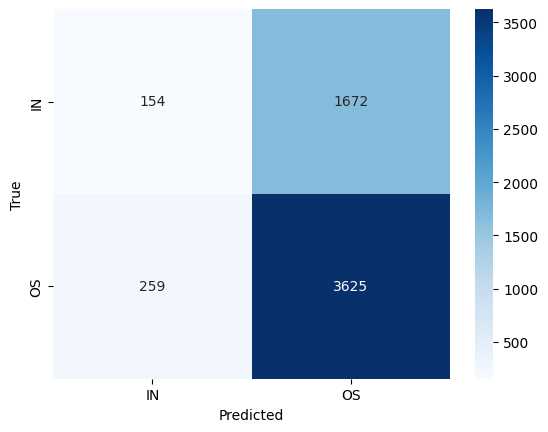

In [24]:
conf = confusion_matrix(test_flat, pred_flat)
import seaborn as sns



sns.heatmap(conf, annot=True,  fmt='d', cmap="Blues",
            xticklabels=['IN','OS'],
            yticklabels=['IN','OS']
          )

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()



The results indicates that the model has a low accuracy of 66%. While it performs well in identifying tokens outside the negation scope (OS), with a F1-score of 0.79. However, the model struggles significantly with identifying tokens inside the negation scope (IN), with only a F1-score of 0.14. One of the reasons could be due to the imbalance in the dataset where OS tokens are way more than IN tokens. 

Additionally, the 2 features I used, while useful, aren't enough to capture the complexity of negation scope. Adding more features would improve the models performance.

In [25]:
### Predict for the dev set
dev = load_data(r"SEM-2012-SharedTask-CD-SCO-dev-09032012-reformatted.txt")

dev_feats, dev_reduced = get_features(dev)
X_dev, y_dev = prepare_data(dev_feats, dev_reduced)
y_dev_pred = crf.predict(X_dev)

## Save Predictions

In [26]:
def save_predictions(y_pred, reduced_dataset, output_file):
    """
    Saves CRF predictions to a TSV file, ensuring correct alignment.
    """
    all_rows = []
    
    for labels, data in zip(y_pred, reduced_dataset):
        sentence_data = data
        
        sentence_data["predicted_scope_label"] = labels
        all_rows.append(sentence_data)

    results_df = pd.concat(all_rows, ignore_index=True)
    results_df.to_csv(output_file, sep="\t", index=False)
    print(f"Predictions saved to {output_file}")

save_predictions(y_pred, test_reduced, "crf_predictions.tsv")
save_predictions(y_dev_pred, dev_reduced, "crf_predictions_dev.tsv")

Predictions saved to crf_predictions.tsv
Predictions saved to crf_predictions_dev.tsv


### Save model

In [27]:
import pickle

with open('A2-group6-model.pkl','wb') as f:
    pickle.dump(crf, f)

### Ready to use function

In [28]:
def negation_scope_detection(model, sentence, cue_indices):
    """
    negation scope detection on a single sentence using the trained model.
    """

    if len(sentence) != len(cues):
        raise ValueError("Sentence and cue lists must have the same length.")

    # Extract features for the input sentence
    doc = nlp(" ".join(sentence))

    dep_graph = build_dependency_graph(doc)

    features = []

    for i, token in enumerate(doc):
        dep_distance = get_dependency_distance(dep_graph, token.i, [j for j, cue in enumerate(cue_indices) if cue == 1])

        feature = {
            "pos": token.pos_,
            "dep_distance":dep_distance,
            
        }
        features.append(feature)

    # Use the trained model to predict the scope
    predictions = model.predict([features])

    return predictions[0]


# Load the trained CRF model
with open("A2-group6-model.pkl", "rb") as f:
    crf_model = pickle.load(f)

# Example sentence and cue
sentence = ["The", "cat", "did", "not", "chase", "the", "mouse", "."]
cues = [0, 0, 0, 1, 0, 0, 0, 0]

# Run the negation scope detection
predicted_scope = negation_scope_detection(crf_model, sentence, cues)

# Output the results
print("Sentence:", " ".join(sentence))
print("Cue Indices:", cues)
print("Predicted Scope:", predicted_scope)

Sentence: The cat did not chase the mouse .
Cue Indices: [0, 0, 0, 1, 0, 0, 0, 0]
Predicted Scope: ['OS' 'OS' 'OS' 'OS' 'OS' 'OS' 'OS' 'OS']
